#  SmartThings Intelligent Device Prediction
## Two-Level Architecture — Full Training Pipeline (10 Epochs)

**Architecture:**
```
SmartThings Cloud → Data Ingestion → Heuristic Scorer → XGBoost + LSTM → Hybrid Fusion → Top Predictions
```

**Dataset:** Samsung SmartSense (snudatalab/SmartSense)  


---

## 1. Setup & Imports

In [59]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = os.path.dirname(os.path.abspath(os.getcwd()))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from Two_level_Arch.src.config import (
    DATA_DIR, MODEL_SAVE_DIR, DEFAULT_COUNTRY,
    HEURISTIC_W1, HEURISTIC_W2, HEURISTIC_W3,
    XGB_PARAMS, LSTM_INPUT_SIZE, LSTM_HIDDEN_SIZE, LSTM_NUM_LAYERS,
    LSTM_DROPOUT, LSTM_BIDIRECTIONAL, LSTM_LR, LSTM_WEIGHT_DECAY,
    LSTM_BATCH_SIZE, LSTM_PATIENCE,
    FUSION_WEIGHTS, TOP_K, DEVICE, RANDOM_SEED, EVAL_K_VALUES,
)
from Two_level_Arch.src.data_loader import (
    download_smartsense, load_country_data, load_dictionary,
    load_routines, instances_to_dataframe,
)
from Two_level_Arch.src.feature_engineering import (
    extract_heuristic_features, extract_xgboost_features,
    extract_lstm_sequences, get_num_devices, get_num_device_controls,
)
from Two_level_Arch.src.dataset import get_dataloaders_from_splits
from Two_level_Arch.src.evaluation import evaluate_all, print_results
from Two_level_Arch.models.heuristic import HeuristicScorer
from Two_level_Arch.models.xgboost_model import ContextualReRanker
from Two_level_Arch.models.lstm_model import RoutinePredictor, train_model
from Two_level_Arch.models.hybrid_fuser import HybridDecisionEngine

# Config
NUM_EPOCHS = 20

# Reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Epochs: {NUM_EPOCHS}")

Device: cuda
PyTorch: 2.10.0+cu128
Epochs: 20


## 2. Download & Load SmartSense Dataset

In [60]:
download_smartsense(DATA_DIR)

[INFO] SmartSense data already exists at /home/saurav/Desktop/Samsung/VIT_25ST07VIT_On-Device_Predictive_Model_Integration_for_SmartThings_Ecosystem/Two_level_Arch/data


'/home/saurav/Desktop/Samsung/VIT_25ST07VIT_On-Device_Predictive_Model_Integration_for_SmartThings_Ecosystem/Two_level_Arch/data'

In [61]:
COUNTRY = DEFAULT_COUNTRY
data_splits = load_country_data(COUNTRY, DATA_DIR)

train_data = data_splits['train']
val_data = data_splits['val']
test_data = data_splits['test']
Extracting XGBoost features...

print(f"\nCountry: {COUNTRY}")
print(f"Train: {train_data.shape}")
print(f"Val:   {val_data.shape}")
print(f"Test:  {test_data.shape}")

SyntaxError: invalid syntax (3396314161.py, line 7)

In [45]:
dictionary = load_dictionary(COUNTRY, DATA_DIR)
if dictionary:
    for key, mapping in dictionary.items():
        print(f"  {key}: {len(mapping)} entries")

routines = load_routines(COUNTRY, DATA_DIR)

all_data = np.concatenate([train_data, val_data, test_data], axis=0)
NUM_DEVICES = get_num_devices(all_data)
NUM_DEVICE_CONTROLS = get_num_device_controls(all_data)

print(f"\nUnique devices: {NUM_DEVICES}")
print(f"Unique device_controls: {NUM_DEVICE_CONTROLS}")

[INFO] Loaded dictionary for 'kr': ['dayofweek_dict', 'hour_dict', 'device_dict', 'device_control_dict']
  dayofweek_dict: 7 entries
  hour_dict: 8 entries
  device_dict: 38 entries
  device_control_dict: 272 entries
[INFO] Loaded 4891 routines for 'kr'

Unique devices: 38
Unique device_controls: 268


## 3. Data Exploration

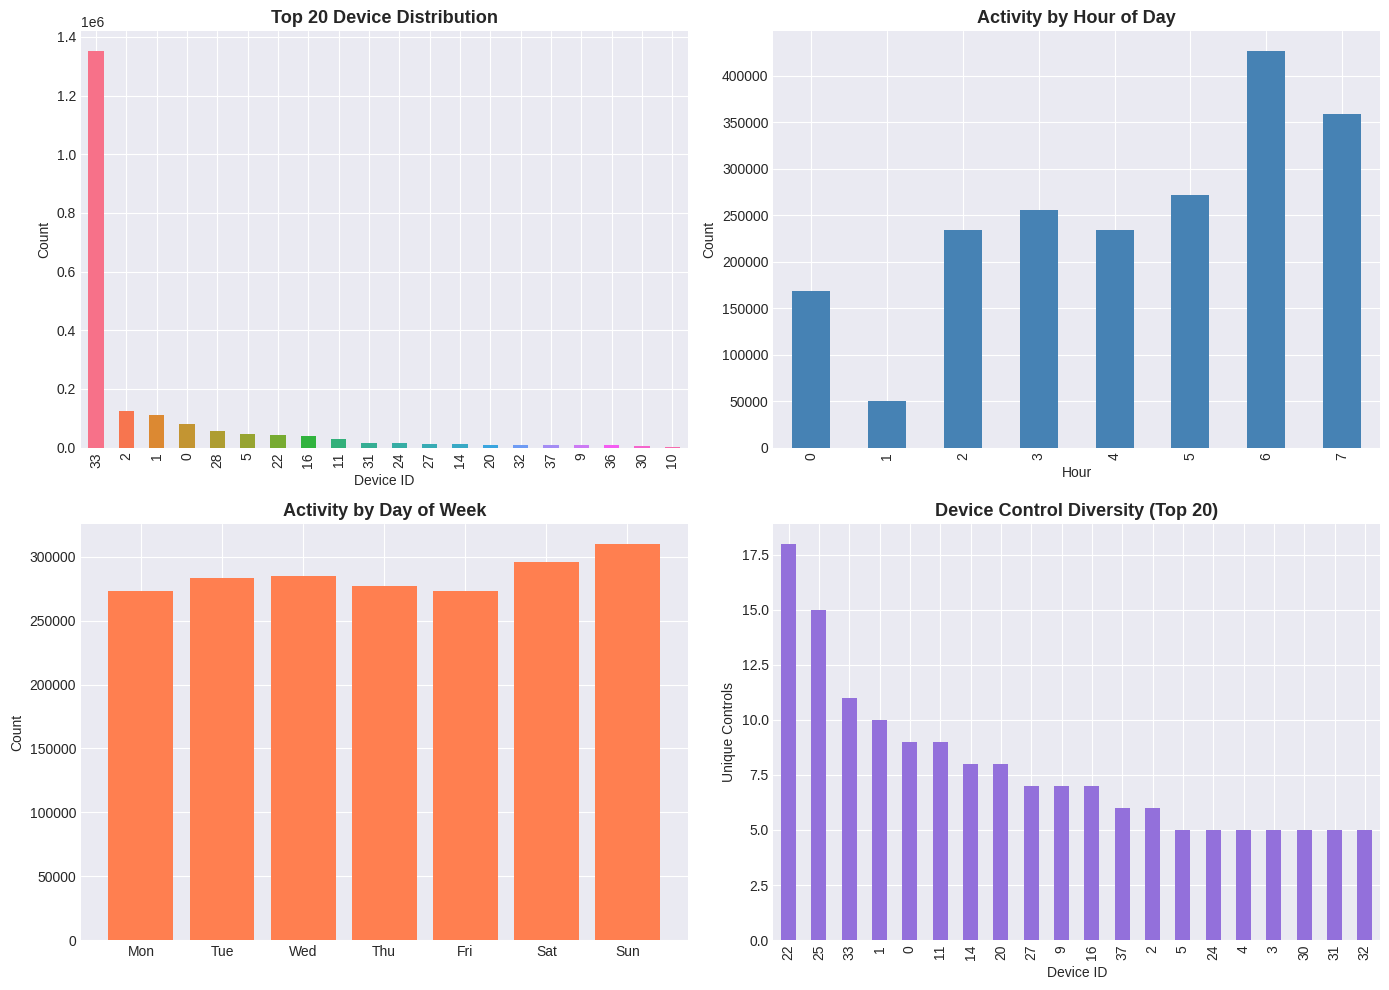

In [49]:
train_df = instances_to_dataframe(train_data)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
device_counts = train_df['device'].value_counts().head(20)
device_counts.plot(kind='bar', ax=ax, color=sns.color_palette('husl', 20))
ax.set_title('Top 20 Device Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Device ID'); ax.set_ylabel('Count')

ax = axes[0, 1]
train_df['hour'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Activity by Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour'); ax.set_ylabel('Count')

ax = axes[1, 0]
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = train_df['day_of_week'].value_counts().sort_index()
ax.bar(range(len(day_counts)), day_counts.values, color='coral')
ax.set_xticks(range(len(day_counts)))
ax.set_xticklabels(day_names[:len(day_counts)])
ax.set_title('Activity by Day of Week', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')

ax = axes[1, 1]
dc_per_device = train_df.groupby('device')['device_control'].nunique().sort_values(ascending=False).head(20)
dc_per_device.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Device Control Diversity (Top 20)', fontsize=13, fontweight='bold')
ax.set_xlabel('Device ID'); ax.set_ylabel('Unique Controls')

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [50]:
# 4.1 Heuristic Features
print("Extracting heuristic features...")
train_heuristic = extract_heuristic_features(train_data, NUM_DEVICES)
val_heuristic = extract_heuristic_features(val_data, NUM_DEVICES)
test_heuristic = extract_heuristic_features(test_data, NUM_DEVICES)
print(f"  Recency: {train_heuristic['recency'].shape}  |  Frequency: {train_heuristic['frequency'].shape}  |  Power: {train_heuristic['power'].shape}")

# 4.2 XGBoost Tabular Features
print("\nExtracting XGBoost features...")
X_train_xgb, y_train_xgb, groups_train = extract_xgboost_features(train_data, NUM_DEVICES)
X_val_xgb, y_val_xgb, groups_val = extract_xgboost_features(val_data, NUM_DEVICES)
X_test_xgb, y_test_xgb, groups_test = extract_xgboost_features(test_data, NUM_DEVICES)
print(f"  X_train: {X_train_xgb.shape}  |  Features: {X_train_xgb.shape[1]}")

# 4.3 LSTM Sequential Features
print("\nExtracting LSTM sequences...")
X_train_lstm, y_train_lstm = extract_lstm_sequences(train_data, normalize=True)
X_val_lstm, y_val_lstm = extract_lstm_sequences(val_data, normalize=True)
X_test_lstm, y_test_lstm = extract_lstm_sequences(test_data, normalize=True)
print(f"  X_train: {X_train_lstm.shape} → y_train: {y_train_lstm.shape}")
print(f"  Unique target devices: {len(np.unique(y_train_lstm))}")

Extracting heuristic features...
  Recency: (199786, 38)  |  Frequency: (199786, 38)  |  Power: (199786, 38)

Extracting XGBoost features...
  X_train: (7591868, 11)  |  Features: 11

Extracting LSTM sequences...
  X_train: (199786, 9, 5) → y_train: (199786,)
  Unique target devices: 27


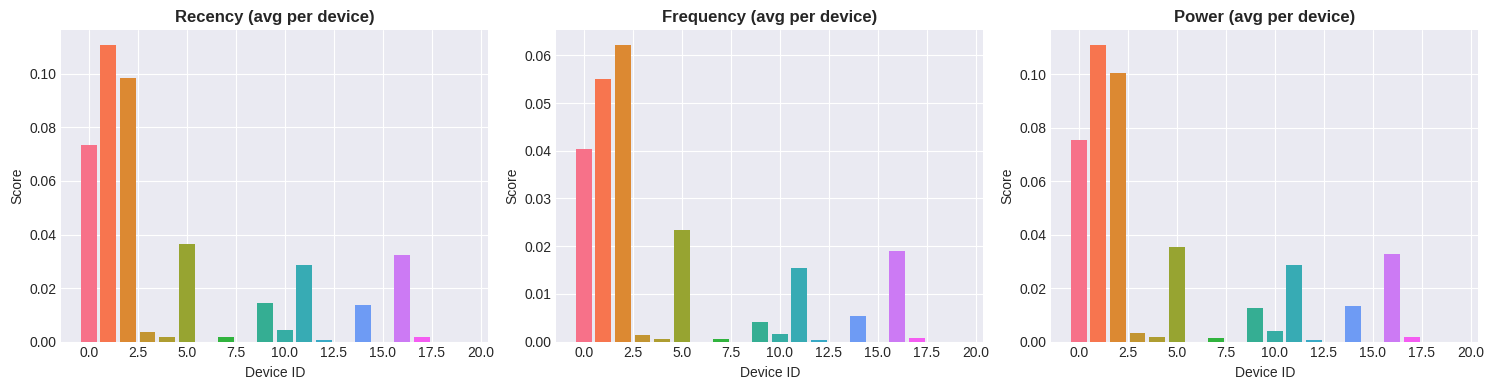

In [51]:
# Feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, feat) in enumerate(train_heuristic.items()):
    ax = axes[idx]
    mean_feat = feat.mean(axis=0)
    ax.bar(range(min(20, NUM_DEVICES)), mean_feat[:20], color=sns.color_palette('husl', 20))
    ax.set_title(f'{name.capitalize()} (avg per device)', fontweight='bold')
    ax.set_xlabel('Device ID'); ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

## 5. Level 1 — Heuristic Scorer

$\text{Score} = w_1 \cdot \text{Recency} + w_2 \cdot \text{Frequency} + w_3 \cdot \text{Power}$

In [52]:
heuristic = HeuristicScorer(w1=HEURISTIC_W1, w2=HEURISTIC_W2, w3=HEURISTIC_W3)
print(heuristic)

heuristic_scores_train = heuristic.rank_batch(
    train_heuristic['recency'], train_heuristic['frequency'], train_heuristic['power'])
heuristic_scores_val = heuristic.rank_batch(
    val_heuristic['recency'], val_heuristic['frequency'], val_heuristic['power'])
heuristic_scores_test = heuristic.rank_batch(
    test_heuristic['recency'], test_heuristic['frequency'], test_heuristic['power'])

test_targets = test_data[:, -1, 2].astype(int)

heuristic_results = evaluate_all(heuristic_scores_test, test_targets, k_values=EVAL_K_VALUES)
print("\n HEURISTIC BASELINE:")
print_results(heuristic_results)

HeuristicScorer(w1=0.40, w2=0.40, w3=0.20)
  Score = 0.4·Recency + 0.4·Frequency + 0.2·Power

 HEURISTIC BASELINE:

  EVALUATION RESULTS
  MRR         : 0.9398
  Hit@1       : 0.8836
  NDCG@1      : 0.8836
  Hit@3       : 0.9998
  NDCG@3      : 0.9554
  Hit@5       : 1.0000
  NDCG@5      : 0.9555
  Hit@10      : 1.0000
  NDCG@10     : 0.9555


## 6. Level 2A — XGBoost Contextual Re-Ranker (Training)

In [53]:
xgb_reranker = ContextualReRanker(params=XGB_PARAMS)

print("Training XGBoost Re-Ranker...")
xgb_reranker.train(
    X_train_xgb, y_train_xgb, groups_train,
    X_val_xgb, y_val_xgb, groups_val
)

xgb_scores_test = xgb_reranker.predict_batch(X_test_xgb, NUM_DEVICES)

xgb_results = evaluate_all(xgb_scores_test, test_targets, k_values=EVAL_K_VALUES)
print("\n XGBoost RE-RANKER:")
print_results(xgb_results)

Training XGBoost Re-Ranker...
[INFO] Training XGBoost Re-Ranker...
  X_train: (7591868, 11), groups: (199786,)
  X_val:   (1084558, 11), groups: (28541,)
[0]	validation_0-ndcg@32:0.94123
[1]	validation_0-ndcg@32:1.00000
[2]	validation_0-ndcg@32:1.00000
[3]	validation_0-ndcg@32:1.00000
[4]	validation_0-ndcg@32:1.00000
[5]	validation_0-ndcg@32:1.00000
[6]	validation_0-ndcg@32:1.00000
[7]	validation_0-ndcg@32:1.00000
[8]	validation_0-ndcg@32:1.00000
[9]	validation_0-ndcg@32:1.00000
[10]	validation_0-ndcg@32:1.00000
[11]	validation_0-ndcg@32:1.00000
[12]	validation_0-ndcg@32:1.00000
[13]	validation_0-ndcg@32:1.00000
[14]	validation_0-ndcg@32:1.00000
[15]	validation_0-ndcg@32:1.00000
[16]	validation_0-ndcg@32:1.00000
[17]	validation_0-ndcg@32:1.00000
[18]	validation_0-ndcg@32:1.00000
[19]	validation_0-ndcg@32:1.00000
[20]	validation_0-ndcg@32:1.00000
[21]	validation_0-ndcg@32:1.00000
[22]	validation_0-ndcg@32:1.00000
[23]	validation_0-ndcg@32:1.00000
[24]	validation_0-ndcg@32:1.00000
[25]	v

KeyboardInterrupt: 

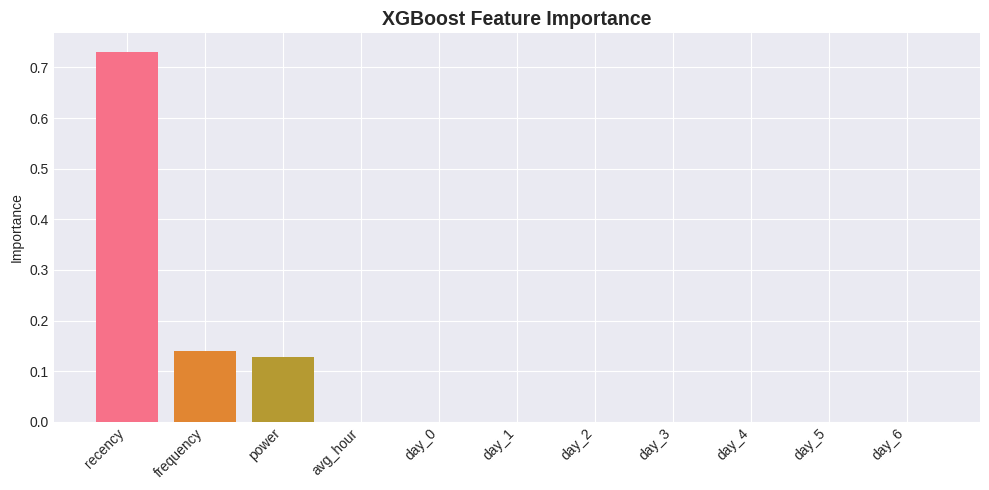

In [15]:
# XGBoost Feature Importance
importance = xgb_reranker.get_feature_importance()
if importance:
    feat_names = ['recency', 'frequency', 'power', 'avg_hour',
                  'day_0', 'day_1', 'day_2', 'day_3', 'day_4', 'day_5', 'day_6']
    imp_vals = list(importance.values())[:len(feat_names)]
    plt.figure(figsize=(10, 5))
    plt.bar(feat_names, imp_vals, color=sns.color_palette('husl', len(feat_names)))
    plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Importance')
    plt.tight_layout()
    plt.show()

## 7. Level 2B — LSTM Routine Predictor (Training — 10 Epochs)

In [16]:
train_loader, val_loader, test_loader = get_dataloaders_from_splits(
    X_train_lstm, y_train_lstm,
    X_val_lstm, y_val_lstm,
    X_test_lstm, y_test_lstm,
    batch_size=LSTM_BATCH_SIZE,
)

lstm_model = RoutinePredictor(
    input_size=LSTM_INPUT_SIZE,
    hidden_size=LSTM_HIDDEN_SIZE,
    num_layers=LSTM_NUM_LAYERS,
    num_devices=NUM_DEVICES,
    dropout=LSTM_DROPOUT,
    bidirectional=LSTM_BIDIRECTIONAL,
).to(DEVICE)

optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LSTM_LR, weight_decay=LSTM_WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"LSTM Parameters: {total_params:,}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

LSTM Parameters: 222,630
Train batches: 781 | Val batches: 112


In [17]:
history = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=NUM_EPOCHS,
    device=DEVICE,
    patience=LSTM_PATIENCE,
)

[INFO] Training LSTM Routine Predictor for 10 epochs on cuda
  Train batches: 781, Val batches: 112


  Epoch   1/10 │ Train Loss: 1.1495 │ Val Loss: 1.0179 │ Val Acc: 0.7402


  Epoch   2/10 │ Train Loss: 0.9387 │ Val Loss: 0.8303 │ Val Acc: 0.7822


  Epoch   3/10 │ Train Loss: 0.8319 │ Val Loss: 0.8038 │ Val Acc: 0.7848


  Epoch   4/10 │ Train Loss: 0.7913 │ Val Loss: 0.7458 │ Val Acc: 0.8021


...

  Epoch   6/10 │ Train Loss: 0.7220 │ Val Loss: 0.6728 │ Val Acc: 0.8144


  Epoch   7/10 │ Train Loss: 0.6925 │ Val Loss: 0.6735 │ Val Acc: 0.8149


  Epoch   8/10 │ Train Loss: 0.6740 │ Val Loss: 0.6308 │ Val Acc: 0.8232


  Epoch   9/10 │ Train Loss: 0.6571 │ Val Loss: 0.6242 │ Val Acc: 0.8221


  Epoch  10/10 │ Train Loss: 0.6430 │ Val Loss: 0.6177 │ Val Acc: 0.8231
[INFO] Restored best model (val_loss=0.6177)
[INFO] LSTM training complete.


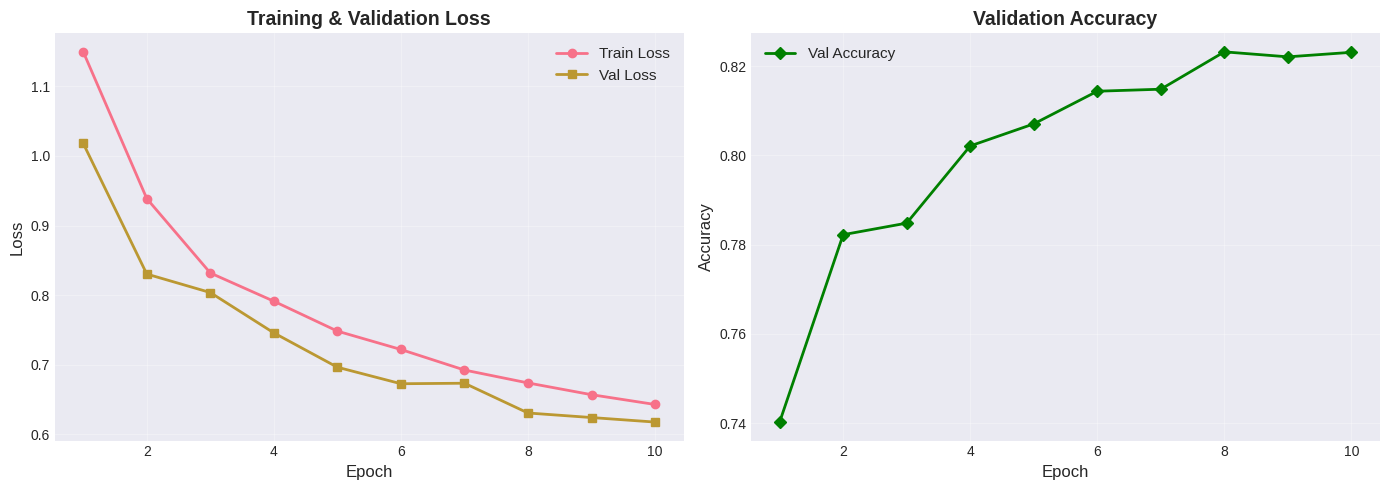

In [18]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(range(1, len(history['train_loss'])+1), history['train_loss'], 'o-', label='Train Loss', linewidth=2, markersize=6)
ax.plot(range(1, len(history['val_loss'])+1), history['val_loss'], 's-', label='Val Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(range(1, len(history['val_acc'])+1), history['val_acc'], 'D-', label='Val Accuracy', linewidth=2, color='green', markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# LSTM Evaluation
lstm_probs_test = lstm_model.predict_numpy(X_test_lstm, device=DEVICE)

lstm_results = evaluate_all(lstm_probs_test, test_targets, k_values=EVAL_K_VALUES)
print("\n LSTM ROUTINE PREDICTOR:")
print_results(lstm_results)


 LSTM ROUTINE PREDICTOR:

  EVALUATION RESULTS
  MRR         : 0.8890
  Hit@1       : 0.8221
  NDCG@1      : 0.8221
  Hit@3       : 0.9483
  NDCG@3      : 0.8984
  Hit@5       : 0.9675
  NDCG@5      : 0.9064
  Hit@10      : 0.9863
  NDCG@10     : 0.9125


## 8. Hybrid Decision Engine — Fusion & Ranking

In [20]:
hybrid = HybridDecisionEngine(weights=FUSION_WEIGHTS)
print(hybrid)

ranked_devices, fused_scores = hybrid.predict(
    heuristic_scores=heuristic_scores_test,
    xgboost_scores=xgb_scores_test,
    lstm_scores=lstm_probs_test,
    top_k=TOP_K,
)

hybrid_results = evaluate_all(fused_scores, test_targets, k_values=EVAL_K_VALUES)
print("\n HYBRID DECISION ENGINE (FINAL):")
print_results(hybrid_results)

HybridDecisionEngine(
  heuristic_weight=0.30,
  xgboost_weight=0.35,
  lstm_weight=0.35
)

 HYBRID DECISION ENGINE (FINAL):

  EVALUATION RESULTS
  MRR         : 0.9539
  Hit@1       : 0.9093
  NDCG@1      : 0.9093
  Hit@3       : 1.0000
  NDCG@3      : 0.9659
  Hit@5       : 1.0000
  NDCG@5      : 0.9659
  Hit@10      : 1.0000
  NDCG@10     : 0.9659


## 9. Model Comparison — All Results

In [21]:
results_comparison = pd.DataFrame({
    'Metric': list(heuristic_results.keys()),
    'Heuristic': [f"{v:.4f}" for v in heuristic_results.values()],
    'XGBoost': [f"{v:.4f}" for v in xgb_results.values()],
    'LSTM': [f"{v:.4f}" for v in lstm_results.values()],
    'Hybrid (Final)': [f"{v:.4f}" for v in hybrid_results.values()],
})

print("\n" + "="*75)
print("   COMPLETE MODEL COMPARISON — Two-Level Architecture")
print("="*75)
print(results_comparison.to_string(index=False))
print("="*75)


   COMPLETE MODEL COMPARISON — Two-Level Architecture
 Metric Heuristic XGBoost   LSTM Hybrid (Final)
    MRR    0.9398  1.0000 0.8890         0.9539
  Hit@1    0.8836  1.0000 0.8221         0.9093
 NDCG@1    0.8836  1.0000 0.8221         0.9093
  Hit@3    0.9998  1.0000 0.9483         1.0000
 NDCG@3    0.9554  1.0000 0.8984         0.9659
  Hit@5    1.0000  1.0000 0.9675         1.0000
 NDCG@5    0.9555  1.0000 0.9064         0.9659
 Hit@10    1.0000  1.0000 0.9863         1.0000
NDCG@10    0.9555  1.0000 0.9125         0.9659


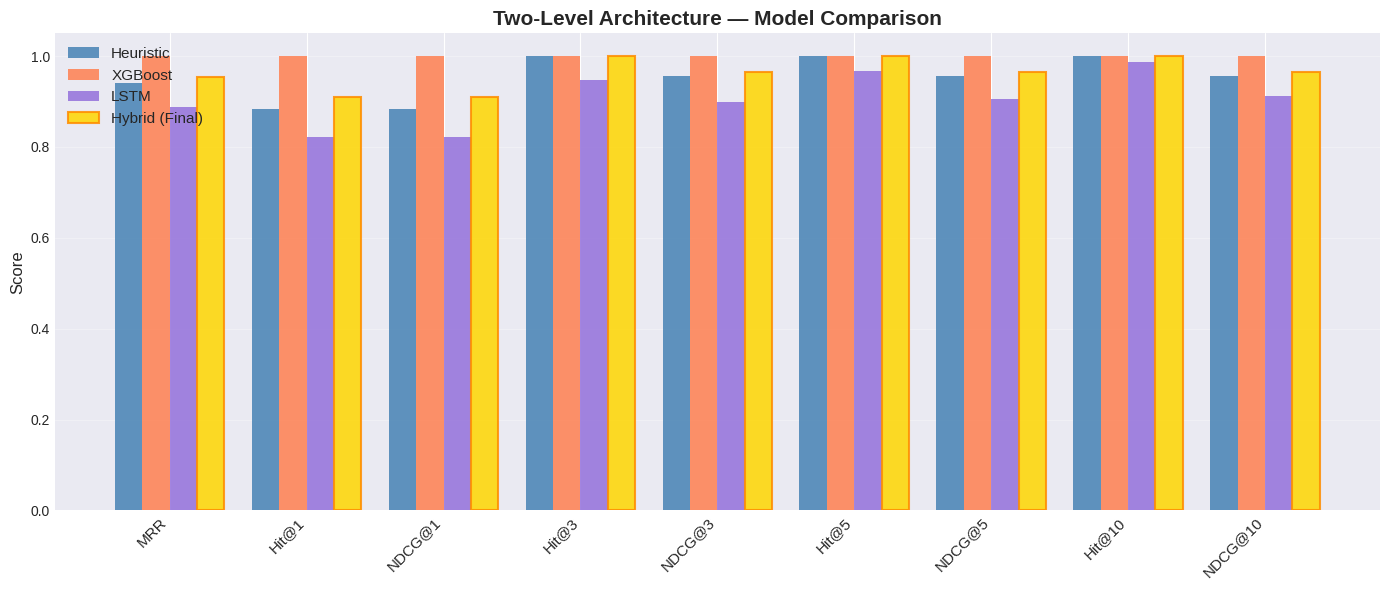

In [22]:
# Visual comparison
metrics = list(heuristic_results.keys())
h_vals = list(heuristic_results.values())
x_vals = list(xgb_results.values())
l_vals = list(lstm_results.values())
hy_vals = list(hybrid_results.values())

x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - 1.5*width, h_vals, width, label='Heuristic', color='steelblue', alpha=0.85)
bars2 = ax.bar(x - 0.5*width, x_vals, width, label='XGBoost', color='coral', alpha=0.85)
bars3 = ax.bar(x + 0.5*width, l_vals, width, label='LSTM', color='mediumpurple', alpha=0.85)
bars4 = ax.bar(x + 1.5*width, hy_vals, width, label='Hybrid (Final)', color='gold', alpha=0.85, edgecolor='darkorange', linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Two-Level Architecture — Model Comparison', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. LSTM Training History (Per-Epoch Data)

In [23]:
epoch_df = pd.DataFrame({
    'Epoch': range(1, len(history['train_loss'])+1),
    'Train Loss': [f"{v:.4f}" for v in history['train_loss']],
    'Val Loss': [f"{v:.4f}" for v in history['val_loss']],
    'Val Accuracy': [f"{v:.4f}" for v in history['val_acc']],
})

print("\n" + "="*55)
print("   LSTM TRAINING HISTORY (10 EPOCHS)")
print("="*55)
print(epoch_df.to_string(index=False))
print("="*55)


   LSTM TRAINING HISTORY (10 EPOCHS)
 Epoch Train Loss Val Loss Val Accuracy
     1     1.1495   1.0179       0.7402
     2     0.9387   0.8303       0.7822
     3     0.8319   0.8038       0.7848
     4     0.7913   0.7458       0.8021
     5     0.7484   0.6965       0.8071
     6     0.7220   0.6728       0.8144
     7     0.6925   0.6735       0.8149
     8     0.6740   0.6308       0.8232
     9     0.6571   0.6242       0.8221
    10     0.6430   0.6177       0.8231


## 11. Sample Predictions — Top Predictions Display

In [26]:
print("   TOP PREDICTIONS — Hybrid Decision Engine")
for sample_idx in range(min(5, len(test_data))):
    scores = fused_scores[sample_idx]
    top_devices = np.argsort(scores)[::-1][:TOP_K]
    true_device = test_targets[sample_idx]

    print(f"\n  Instance {sample_idx} | True next device: {true_device}")
    print(f"  {'Rank':<6} {'Device':<12} {'Score':<10} {'Match'}")
    print(f"  {'─'*40}")
    for rank, dev_id in enumerate(top_devices, 1):
        match = "done" if dev_id == true_device else ""
        print(f"  {rank:<6} device_{dev_id:<6} {scores[dev_id]:<10.4f} {match}")

   TOP PREDICTIONS — Hybrid Decision Engine

  Instance 0 | True next device: 33
  Rank   Device       Score      Match
  ────────────────────────────────────────
  1      device_33     1.0000     done
  2      device_9      0.1330     
  3      device_36     0.0046     
  4      device_28     0.0044     
  5      device_11     0.0042     

  Instance 1 | True next device: 33
  Rank   Device       Score      Match
  ────────────────────────────────────────
  1      device_33     1.0000     done
  2      device_28     0.0015     
  3      device_1      0.0012     
  4      device_0      0.0009     
  5      device_36     0.0003     

  Instance 2 | True next device: 33
  Rank   Device       Score      Match
  ────────────────────────────────────────
  1      device_33     1.0000     done
  2      device_28     0.0015     
  3      device_1      0.0012     
  4      device_0      0.0009     
  5      device_36     0.0003     

  Instance 3 | True next device: 33
  Rank   Device       Sco

## 12. Save Trained Models

In [25]:
xgb_reranker.save_model()
lstm_model.save_model()
print(f"\n All models saved to {MODEL_SAVE_DIR}")

[INFO] XGBoost model saved to /home/saurav/Desktop/Samsung/VIT_25ST07VIT_On-Device_Predictive_Model_Integration_for_SmartThings_Ecosystem/Two_level_Arch/saved_models/xgboost_reranker.json
[INFO] LSTM model saved to /home/saurav/Desktop/Samsung/VIT_25ST07VIT_On-Device_Predictive_Model_Integration_for_SmartThings_Ecosystem/Two_level_Arch/saved_models/lstm_routine_predictor.pt

 All models saved to /home/saurav/Desktop/Samsung/VIT_25ST07VIT_On-Device_Predictive_Model_Integration_for_SmartThings_Ecosystem/Two_level_Arch/saved_models


In [28]:
import numpy as np

# ---- 1️⃣ Basic shape checks ----
print("Predictions shape:", xgb_scores_test.shape)
print("Targets shape:", test_targets.shape)
try:
    print("Groups shape:", len(groups_test))
except NameError:
    print("No 'groups_test' variable found. Make sure to check group alignment manually.")

# ---- 2️⃣ Inspect first few rows ----
num_rows_to_check = 5
for i in range(num_rows_to_check):
    pred_row = xgb_scores_test[i]
    target_row = test_targets[i]

    top_idx = np.argmax(pred_row)
    target_idx = np.argmax(target_row) if target_row.ndim == 1 else np.where(target_row == 1)[0]

    print(f"\nRow {i}:")
    print("Predictions:", pred_row)
    print("Target indices:", target_idx)
    print("Top predicted index:", top_idx)
    if top_idx in target_idx:
        print("✅ Top prediction matches target")
    else:
        print("❌ Top prediction does NOT match target")

# ---- 3️⃣ Check for duplicated rows between train/test (common leakage) ----
if 'X_train_xgb' in globals():
    duplicated_rows = np.isin(xgb_scores_test, X_train_xgb).sum()
    print("\nNumber of prediction rows duplicated in training data (possible leakage):", duplicated_rows)

# ---- 4️⃣ Check distribution of scores ----
print("\nScore statistics:")
print("Min score:", xgb_scores_test.min())
print("Max score:", xgb_scores_test.max())
print("Mean score:", xgb_scores_test.mean())
print("Number of unique scores:", len(np.unique(xgb_scores_test)))

# ---- 5️⃣ Shuffle test predictions to see metric impact ----
try:
    shuffled_preds = np.copy(xgb_scores_test)
    for i in range(shuffled_preds.shape[0]):
        np.random.shuffle(shuffled_preds[i])

    print("\nShuffling predictions to test metric sensitivity...")
    shuffled_results = evaluate_all(shuffled_preds, test_targets)
    print_results(shuffled_results)
except Exception as e:
    print("Error during shuffling test:", e)

Predictions shape: (57082, 38)
Targets shape: (57082,)
Groups shape: 57082

Row 0:
Predictions: [-6.713113  -6.713113  -6.713113  -6.713113  -6.713113  -6.713113
 -6.713113  -6.713113  -6.713113  -4.0624647 -6.713113  -6.713113
 -6.713113  -6.713113  -6.713113  -6.713113  -6.713113  -6.713113
 -6.713113  -6.713113  -6.713113  -6.713113  -6.713113  -6.713113
 -6.713113  -6.713113  -6.713113  -6.713113  -6.713113  -6.713113
 -6.713113  -6.713113  -6.713113   6.4159374 -6.713113  -6.713113
 -6.713113  -6.713113 ]
Target indices: []
Top predicted index: 33
❌ Top prediction does NOT match target

Row 1:
Predictions: [-6.713113  -6.713113  -6.713113  -6.713113  -6.713113  -6.713113
 -6.713113  -6.713113  -6.713113  -6.713113  -6.713113  -6.713113
 -6.713113  -6.713113  -6.713113  -6.713113  -6.713113  -6.713113
 -6.713113  -6.713113  -6.713113  -6.713113  -6.713113  -6.713113
 -6.713113  -6.713113  -6.713113  -6.713113  -6.713113  -6.713113
 -6.713113  -6.713113  -6.713113   6.5578823 -6.713

In [30]:
num_queries = xgb_scores_test.shape[0]
num_candidates = xgb_scores_test.shape[1]

# Assuming test_targets currently contains the index of the correct candidate per query
targets_matrix = np.zeros((num_queries, num_candidates), dtype=int)
for i, idx in enumerate(test_targets):  # idx = correct candidate index
    if idx >= 0:  # skip invalid/missing
        targets_matrix[i, idx] = 1

# Now use targets_matrix in evaluate_all
xgb_results1 = evaluate_all(xgb_scores_test, targets_matrix, k_values=EVAL_K_VALUES)
print_results(xgb_results1)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()